<h1>Prosjektoppgave - Support Dashboard PY1010</h1>
<p>Innleveringen skal inneholde kjørbar kode (en py-fil eller JNB-fil (Jupyter Notebook) hvor alle
deloppgavene besvares i en og samme fil). All kode skal dokumenteres med korte
informative kommentarer. Et viktig moment med innleveringen er at koden du leverer fra
deg er grundig testet og at den er kjørbar for mottaker.
Den ferdigdefinerte oppgaven består av 6 deloppgaver, hvor minst 5 av de 6 deloppgavene
skal besvares. Oppgaven Support dashboard er gitt nedenfor.

<br>
</p>
<p>
Du skal her utføre diverse analyser av data som er loggført for supportavdelingen ved 
telefonselskapet MORSE. Enhver kundehenvendelse til MORSE blir loggført i en xlsx-fil og du 
skal i dette prosjektet jobbe med dataloggen for uke 24. Filen ‘support_uke_24.xlsx’ finner 
du sammen med prosjektoppgaven i Canvas under menyen Oppgaver -> Prosjektoppgaven, 
og filen er organisert på følgende måte: 
    <br>
<ul>
<li>Kolonne 1: Ukedag henvendelsen fant sted</li>
<li>Kolonne 2: Klokkeslett kunden tok kontakt med supportavdelingen</li>
<li>Kolonne 3: Samtalens varighet</li>
<li>Kolonne 4: Kundens tilfredshet (skala fra 1-10 hvor 1 indikerer svært misfornøyd og 10 
indikerer svært fornøyd).</li> 
Merk: kolonne 4 er ikke komplett da mange kunder unnlater å gi tilbakemelding på sin 
tilfredshet. 
</p>

<p>
<strong>Del a)</strong> 
<br>    
Skriv et program som leser inn filen ‘support_uke_24.xlsx’ og lagrer data fra kolonne 1 
i en array med variablenavn ‘u_dag’, dataen i kolonne 2 lagres i arrayen ‘kl_slett’, data i 
kolonne 3 lagres i arrayen ‘varighet’ og dataen i kolonne 4 lagres i arrayen ‘score’.  Merk: 
filen ‘support_uke_24.xlsx’ må ligge i samme mappe som Python-programmet ditt. 
</p>

In [2]:
  # Svar på del a

import pandas as pd 

df = pd.read_excel('support_uke_24.xlsx')  # leser inn excel-fil i samme mappe

u_dag = df.iloc[:, 0].values
kl_slett = df.iloc[:, 1].values
varighet = df.iloc[:, 2].values
score = df.iloc[:, 3].dropna().values   # manglende tilbakemeldinger fjernes


  # kontroll av to rader. Man kan endre tall-verdien for å få vist flere verdier fra excelfilen.
print(f"Ukedag: {u_dag[:2]}")
print(f"Klokkeslett: {kl_slett[:2]}")
print(f"Varighet: {varighet[:2]}")
print(f"Kundescore: {score[:2]}")





Ukedag: ['Mandag' 'Mandag']
Klokkeslett: ['08:04:16' '08:04:53']
Varighet: ['00:07:12' '00:02:49']
Kundescore: [6. 8.]


<p>
<strong>Del b)</strong> 
<br>
Skriv et program som finner antall henvendelser for hver de 5 ukedagene. Resultatet 
visualiseres ved bruk av et søylediagram (stolpediagram).
</p>

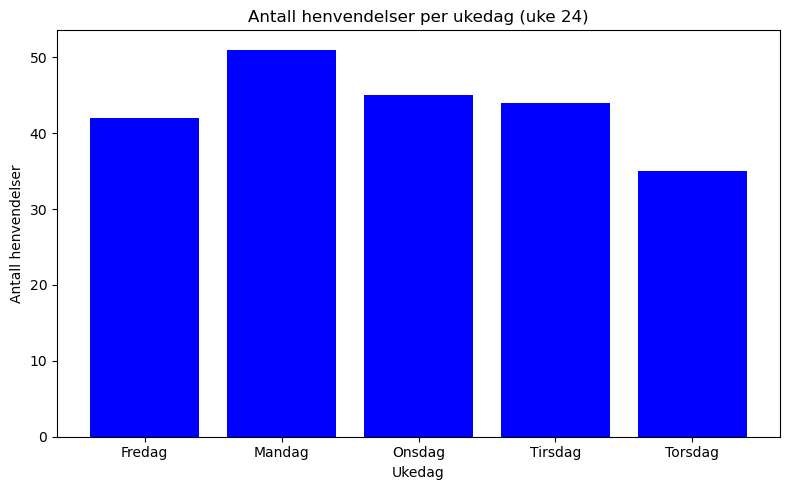

In [3]:
# Svar på del b

import matplotlib.pyplot as plt

# Tell antall henvendelser per ukedag
ukedag_telling = df.iloc[:, 0].value_counts().sort_index()

# Visualisering
plt.figure(figsize=(8,5))
plt.bar(ukedag_telling.index, ukedag_telling.values, color='blue')
plt.xlabel('Ukedag')
plt.ylabel('Antall henvendelser')
plt.title('Antall henvendelser per ukedag (uke 24)')
plt.tight_layout()
plt.show()




<p>
<strong>Del c)</strong> 
<br>
Skriv et program som finner minste og lengste samtaletid som er loggført for uke 24. 
Svaret skrives til skjerm med informativ tekst. 
</p>

In [4]:
# Svar på del c

import pandas as pd

# Leser inn filen ( finnes allerede men legger inn her også)
df = pd.read_excel('support_uke_24.xlsx')

# Hent varighet-kolonnen
varighet = df.iloc[:, 2]

# Konverter tekst til tidsobjekter (timedelta)
varighet_td = pd.to_timedelta(varighet)

# Finn korteste og lengste samtaletid
korteste = varighet_td.min()
lengste = varighet_td.max()

# Skriv resultat til skjerm
print(f"Den korteste samtaletiden i uke 24 var: {korteste}")
print(f"Den lengste samtaletiden i uke 24 var: {lengste}")


Den korteste samtaletiden i uke 24 var: 0 days 00:00:59
Den lengste samtaletiden i uke 24 var: 0 days 00:11:28


<p>
<strong>Del d)</strong> 
<br>
KREVENDE: Skriv et program som regner ut gjennomsnittlig samtaletid basert på alle 
henvendelser i uke 24.  
</p>

In [5]:
# Svar på del d

import pandas as pd

df = pd.read_excel('support_uke_24.xlsx')

varighet = df.iloc[:, 2]
varighet_td = pd.to_timedelta(varighet)

gjennomsnitt = varighet_td.mean()

# Fjerner mange desimaler når man bruker timedelta som tar med seg alt. Vil ha TT:MM:SS
gjennomsnitt_str = str(gjennomsnitt).split('.')[0]

print(f"Den gjennomsnittlige samtaletiden i uke 24 var: {gjennomsnitt_str}")



Den gjennomsnittlige samtaletiden i uke 24 var: 0 days 00:06:40


<p>
<strong>Del e)</strong> 
<br>
Supportvaktene i MORSE er delt inn i 2-timers bolker: kl 08-10, kl 10-12, kl 12-14 og kl 
14-16. Skriv et program som finner det totale antall henvendelser supportavdelingen mottok 
for hver av tidsrommene 08-10, 10-12, 12-14 og 14-16 for uke 24. Resultatet visualiseres ved 
bruk av et sektordiagram (kakediagram). 
</p>

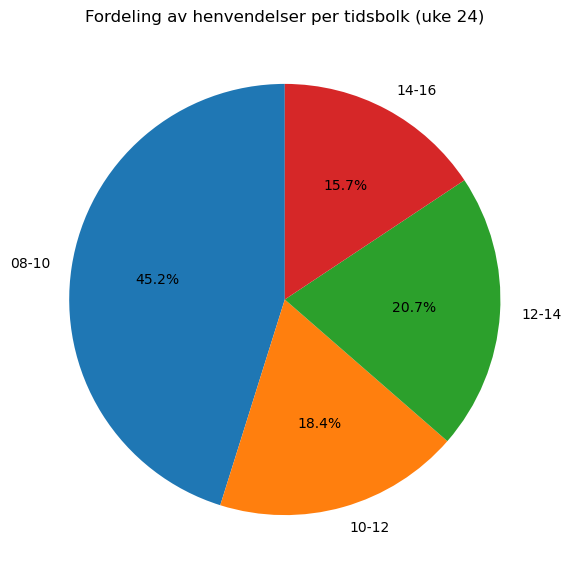

In [10]:
# Svar på oppgave del E

import pandas as pd
import matplotlib.pyplot as plt

# df finnes allerede når kjørt i oppgave over, men er med her likevel
df = pd.read_excel('support_uke_24.xlsx')

# Hent klokkeslett-kolonnen
kl_slett = df.iloc[:, 1]

# Konverter klokkeslett til datetime
kl_slett_dt = pd.to_datetime(kl_slett, format='%H:%M:%S').dt.time

# Funksjon som plasserer tidspunkt i 2-timers tidsbolker
def finn_bolk(tid):
    if pd.to_datetime("08:00:00").time() <= tid < pd.to_datetime("10:00:00").time():
        return "08-10"
    elif pd.to_datetime("10:00:00").time() <= tid < pd.to_datetime("12:00:00").time():
        return "10-12"
    elif pd.to_datetime("12:00:00").time() <= tid < pd.to_datetime("14:00:00").time():
        return "12-14"
    elif pd.to_datetime("14:00:00").time() <= tid < pd.to_datetime("16:00:00").time():
        return "14-16"
    else:
        return "Utenfor vakt"   # skal ikke forekomme i uke 24

# Lag ny kolonne med tidsbolk
df["Tidsbolk"] = [finn_bolk(t) for t in kl_slett_dt]

# Tell antall henvendelser per tidsbolk
bolk_telling = df["Tidsbolk"].value_counts().sort_index()

# Sektordiagram
plt.figure(figsize=(7,7))
plt.pie(bolk_telling.values, labels=bolk_telling.index, autopct='%1.1f%%', startangle=90)
plt.title("Fordeling av henvendelser per tidsbolk (uke 24)")
plt.show()


<p>
<strong>Del f)</strong> 
<br>
Kundens tilfredshet loggføres som tall fra 1-10 hvor 1 indikerer svært misfornøyd og 
10 indikerer svært fornøyd. Disse tilbakemeldingene skal så overføres til NPS-systemet (Net 
Promoter Score).  
NPS-systemet er konstruert på følgende måte: 
<br>
Score 1-6 oppfattes som at kunden er negativ (vil trolig ikke anbefale MORSE til andre). <br>
Score 7-8 oppfattes som et nøytralt svar.<br> 
Score 9-10 oppfattes som at kunden er positiv (vil trolig anbefale MORSE til andre).  <br>
    <br>
Supportavdelingens NPS beregnes som et tall, prosentandelen positive kunder minus 
prosentandelen negative kunder. Ved en formel kan dette gis slik: 
<br>
NPS = % positive kunder - % negative kunder <br>
Et eksempel på utregning av NPS er gitt i figuren under.
</p>

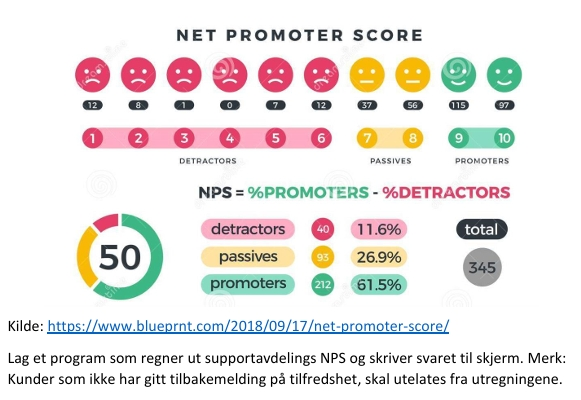


In [11]:
# Svar på del f

import pandas as pd

# Leser inn fil
df = pd.read_excel('support_uke_24.xlsx')

# Hent kundescore-kolonnen
score = df.iloc[:, 3]

# Fjern rader uten score (NaN)
score = score.dropna()

# Tell antall i hver kategori
antall_total = len(score)
antall_negativ = len(score[(score >= 1) & (score <= 6)])
antall_noytral = len(score[(score >= 7) & (score <= 8)])
antall_positiv = len(score[(score >= 9) & (score <= 10)])

# Beregn prosentandeler
prosent_negativ = (antall_negativ / antall_total) * 100
prosent_positiv = (antall_positiv / antall_total) * 100

# Beregn NPS (Net Promoter Score)
NPS = prosent_positiv - prosent_negativ

# Skriv resultat til skjerm
print(f"Totalt antall kunder som ga score: {antall_total}")
print(f"Antall negative (1-6): {antall_negativ}")
print(f"Antall nøytrale (7-8): {antall_noytral}")
print(f"Antall positive (9-10): {antall_positiv}")
print()
print(f"Prosent negative: {prosent_negativ:.1f}%")
print(f"Prosent positive: {prosent_positiv:.1f}%")
print()
print(f"Supportavdelingens NPS for uke 24 er: {NPS:.1f}")


Totalt antall kunder som ga score: 43
Antall negative (1-6): 10
Antall nøytrale (7-8): 5
Antall positive (9-10): 28

Prosent negative: 23.3%
Prosent positive: 65.1%

Supportavdelingens NPS for uke 24 er: 41.9
